# Exploratory Data Analysis

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
ufc_data_path = '../data/raw/ufc-master.csv'
ufc_data = pd.read_csv(ufc_data_path)

## Hypothesis 1 - Reach advantage

I believe fighters with a reach advantage are more likely to win because a longer reach allows them to strike from a safer distance.

### Create analysis dataset 

Use a boolean mask to filter fights with non-zero reach difference

In [7]:
non_zero_reach_mask = ufc_data['reach_dif'] != 0

In [8]:
non_zero_reach_df = ufc_data[non_zero_reach_mask]
non_zero_reach_df.head()

,R_fighter,B_fighter,R_odds,B_odds,R_ev,B_ev,date,location,country,Winner,...,finish_details,finish_round,finish_round_time,total_fight_time_secs,r_dec_odds,b_dec_odds,r_sub_odds,b_sub_odds,r_ko_odds,b_ko_odds
0,Israel Adesanya,Joe Pyfer,-130.0,102.0,76.9231,102.0000,2026-03-28,"Seattle, Washington, USA",USA,Blue,...,Punches,2.0,4:18,558.0,163.0,900.0,2500.0,400.0,300.0,250.0
1,Alexa Grasso,Maycee Barber,124.0,-158.0,124.0000,63.2911,2026-03-28,"Seattle, Washington, USA",USA,Red,...,Punch,1.0,2:42,162.0,175.0,105.0,1400.0,800.0,2500.0,500.0
2,Michael Chiesa,Niko Price,-901.0,550.0,11.0988,550.0000,2026-03-28,"Seattle, Washington, USA",USA,Red,...,Rear Naked Choke,1.0,1:03,63.0,225.0,900.0,-150.0,1600.0,600.0,1000.0
3,Julian Erosa,Lerryan Douglas,235.0,-320.0,235.0000,31.2500,2026-03-28,"Seattle, Washington, USA",USA,Blue,...,Punches,1.0,3:33,213.0,600.0,500.0,600.0,2000.0,700.0,-150.0
4,Mansur Abdul-Malik,Yousri Belgaroui,-158.0,124.0,63.2911,124.0000,2026-03-28,"Seattle, Washington, USA",USA,Blue,...,Knee,3.0,3:39,819.0,350.0,240.0,800.0,1800.0,240.0,250.0


### Filter fights where reach advantage won

In [9]:
reach_advantage_mask = (((non_zero_reach_df['reach_dif'] > 0) & (non_zero_reach_df['Winner'] == 'Red')) | ((non_zero_reach_df['reach_dif'] < 0) & (non_zero_reach_df['Winner'] == 'Blue')))

In [10]:
reach_advantage_counts = reach_advantage_mask.value_counts()

### Compute empirical probability

In [11]:
reach_advantage_mask.mean()

np.float64(0.4809925242564021)

### Validation

In [12]:
pd.DataFrame({
    "reach_dif": non_zero_reach_df["reach_dif"],
    "Winner": non_zero_reach_df["Winner"],
    "Mask": reach_advantage_mask
}).sample(15, random_state=42)

,reach_dif,Winner,Mask
5079,-5.08,Red,False
4179,7.62,Blue,False
6931,-2.54,Red,False
6076,-10.16,Blue,True
1755,5.08,Red,True
3807,-2.54,Red,False
347,7.62,Red,True
4822,-5.08,Blue,True
4465,-7.62,Red,False
6899,15.24,Red,True


In [13]:
non_zero_reach_df[
    ["reach_dif", "Winner"]
].head(10)

,reach_dif,Winner
0,-12.70,Blue
1,-2.54,Red
2,2.54,Red
3,-5.08,Blue
4,-2.54,Blue
5,-5.08,Red
6,-15.24,Blue
7,-5.08,Blue
8,-7.62,Blue
9,-7.62,Red


In [14]:
red_reach_wins = (
    (non_zero_reach_df["reach_dif"] > 0)
    & (non_zero_reach_df["Winner"] == "Red")
)

blue_reach_wins = (
    (non_zero_reach_df["reach_dif"] < 0)
    & (non_zero_reach_df["Winner"] == "Blue")
)

(red_reach_wins.sum() + blue_reach_wins.sum()) / len(non_zero_reach_df)

np.float64(0.4809925242564021)

### Plot

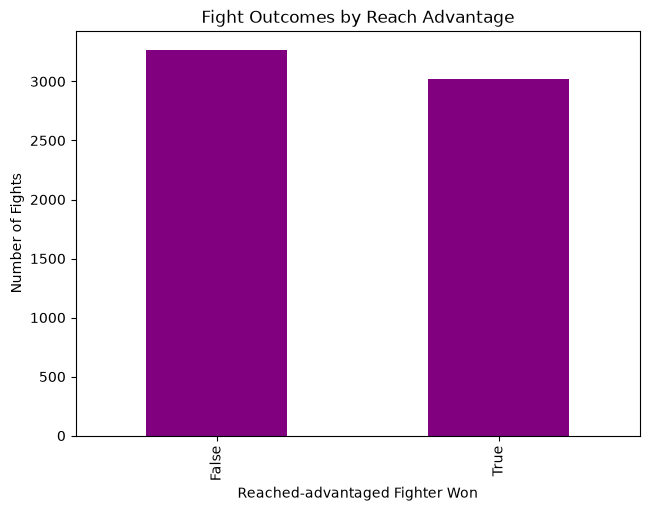

In [15]:
reach_advantage_counts.plot(kind='bar', color='purple')
plt.tight_layout()
plt.xlabel('Reached-advantaged Fighter Won')
plt.ylabel('Number of Fights')
plt.title('Fight Outcomes by Reach Advantage')
plt.show()

### Findings

- Excluded fights where neither fighter had a reach advantage (`reach_dif == 0`).
- Among the remaining fights, the fighter with the reach advantage won **48.099%** of the time.
- The observed win rate (48.1%) is below 50%, suggesting that reach advantage alone does not provide an observable advantage in this dataset.
- The initial hypothesis is not supported by this analysis.

### Conclusion

Based on this dataset, reach advantage alone does not appear to increase the probability of winning a UFC fight.

However, this analysis considers only reach difference in isolation. Other variables such as age, experience, betting odds, rankings, and weight class may interact with reach and should be investigated before drawing stronger conclusions.

## Hypothesis 2 - Age factor

I believe younger fighters are more likely to win because they generally have better athleticism and recovery.

In [17]:
unequal_age_mask = ufc_data['R_age'] != ufc_data['B_age']

In [18]:
unequal_age_df = ufc_data[unequal_age_mask]
unequal_age_df.head()

,R_fighter,B_fighter,R_odds,B_odds,R_ev,B_ev,date,location,country,Winner,...,finish_details,finish_round,finish_round_time,total_fight_time_secs,r_dec_odds,b_dec_odds,r_sub_odds,b_sub_odds,r_ko_odds,b_ko_odds
0,Israel Adesanya,Joe Pyfer,-130.0,102.0,76.9231,102.0000,2026-03-28,"Seattle, Washington, USA",USA,Blue,...,Punches,2.0,4:18,558.0,163.0,900.0,2500.0,400.0,300.0,250.0
1,Alexa Grasso,Maycee Barber,124.0,-158.0,124.0000,63.2911,2026-03-28,"Seattle, Washington, USA",USA,Red,...,Punch,1.0,2:42,162.0,175.0,105.0,1400.0,800.0,2500.0,500.0
2,Michael Chiesa,Niko Price,-901.0,550.0,11.0988,550.0000,2026-03-28,"Seattle, Washington, USA",USA,Red,...,Rear Naked Choke,1.0,1:03,63.0,225.0,900.0,-150.0,1600.0,600.0,1000.0
3,Julian Erosa,Lerryan Douglas,235.0,-320.0,235.0000,31.2500,2026-03-28,"Seattle, Washington, USA",USA,Blue,...,Punches,1.0,3:33,213.0,600.0,500.0,600.0,2000.0,700.0,-150.0
4,Mansur Abdul-Malik,Yousri Belgaroui,-158.0,124.0,63.2911,124.0000,2026-03-28,"Seattle, Washington, USA",USA,Blue,...,Knee,3.0,3:39,819.0,350.0,240.0,800.0,1800.0,240.0,250.0


### Filter fights where younger fighter won

In [19]:
age_advantage_mask = ((unequal_age_df['R_age'] < unequal_age_df['B_age']) & (unequal_age_df['Winner'] == 'Red') | ((unequal_age_df['B_age'] < unequal_age_df['R_age']) & (unequal_age_df['Winner'] == 'Blue')))

In [20]:
age_advantage_counts = age_advantage_mask.value_counts()
print(age_advantage_counts)

True     3804
False    2831
Name: count, dtype: int64


### Compute Empirical Probability

In [21]:
younger_fighter_win_rate = age_advantage_mask.mean()
print(younger_fighter_win_rate)

0.5733232856066315


### Findings

- After excluding fights where both fighters were the same age, the younger fighter won approximately **57.3%** of the fights.
- This suggests that younger fighters have a higher observed win rate than older fighters.
- The effect appears stronger than the reach advantage investigated previously.

### Conclusion

The results provide evidence that age is associated with fight outcomes. In this dataset, the younger fighter won more often than the older fighter.

However, age alone is unlikely to determine the outcome of a fight. Other factors such as experience, rankings, betting odds, and fighting style may also influence the result and should be investigated.